## Geocalibration

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from scipy.optimize import minimize
import itertools
from tqdm import tqdm
from typing import List
import json

In [44]:
to_vec_comma = lambda x: np.array([float(i) for i in x[1:-1].split(",")])
to_vec_space = lambda x: np.array([float(i.strip()) for i in x[1:-1].split(" ") if len(i)])
to_mat = lambda x: np.array([[float(val.strip()) for val in r[1:-1].split(" ") if len(val)] for r in x[1:-1].split("\n ")])

# function for parsing data
def get_zl_zr(f_str:str, data:pd.DataFrame):
    """
    Extract the data for focus [f_str] for ZL and ZR cameras
    f_str: str, string of the focus number
    data: pd.DataFrame, the data
    """
    d_left = data[data["cam"]==f"ZL{f_str}"].copy().reset_index(drop=True)
    d_right = data[data["cam"]==f"ZR{f_str}"].copy().reset_index(drop=True)
    return d_left, d_right

def parse_cahvor(z_data:pd.DataFrame):
  """
  return the data with the cahvor parameters parsed
  """
  z_data["c_r_vec"] = z_data["c_r_est"].apply(to_vec_space)
  z_data["h_r_vec"] = z_data["h_r_est"].apply(to_vec_space)
  z_data["v_r_vec"] = z_data["v_r_est"].apply(to_vec_space)
  z_data["a_r_vec"] = z_data["a_r_est"].apply(to_vec_space)
  z_data["R_rpm_mat"] = z_data["R_rpm"].apply(to_mat)
  z_data["t_rpm_vec"] = z_data["t_rpm"].apply(to_vec_comma)

# Functions for Iterative Kabsch algorithm fits and plots
def solve_r_mc(data_, rot_rrp, lambda_h, lambda_v, lambda_a):
  R_rrp = rot_rrp.as_matrix()

  m_frame, c_frame = [], []
  for i in range(data_.shape[0]):
    # compute h^m from hr
    hr = get_H_r_data(i, data_)
    R_rpm = get_R_rpm(i, data_)
    
    scaled_hm = (R_rrp @ R_rpm).T @ hr @ np.diag([lambda_h, lambda_v, lambda_a])
    m_frame.append(list(scaled_hm[:,0]))
    m_frame.append(list(scaled_hm[:,1]))
    m_frame.append(list(scaled_hm[:,2]))

    # compute hm from hc
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = np.array([[fl+b1, 0, 0],
        [b2, fl, 0],
        [cx, cy, 1]])
    scaled_hc = hc @ np.diag([lambda_h, lambda_v, lambda_a])
    c_frame.append(scaled_hc[:,0])
    c_frame.append(scaled_hc[:,1])
    c_frame.append(scaled_hc[:,2])

  m_frame_arr = np.array(m_frame)
  c_frame_arr = np.array(c_frame)

  rot_mc, rssd = R.align_vectors(m_frame_arr, c_frame_arr, return_sensitivity=False)

  return rot_mc, rssd

def solve_r_rrp(data_, rot_mc, lambda_h, lambda_v, lambda_a):

  R_mc = rot_mc.as_matrix()

  r_frame, rp_frame = [], []
  for i in range(data_.shape[0]):
    # compute Hr
    hr = get_H_r_data(i, data_)
    scaled_hr = hr @ np.diag([lambda_h, lambda_v, lambda_a])
    r_frame.append(list(scaled_hr[:,0]))
    r_frame.append(list(scaled_hr[:,1]))
    r_frame.append(list(scaled_hr[:,2]))

    # compute hc
    R_rpm = get_R_rpm(i, data_)
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    scaled_hrp = R_rpm @ R_mc @ hc @ np.diag([lambda_h, lambda_v, lambda_a])
    rp_frame.append(list(scaled_hrp[:,0]))
    rp_frame.append(list(scaled_hrp[:,1]))
    rp_frame.append(list(scaled_hrp[:,2]))

  r_frame_arr = np.array(r_frame)
  rp_frame_arr = np.array(rp_frame)

  rot_rrp, rssd = R.align_vectors(r_frame_arr, rp_frame_arr, return_sensitivity=False)
  
  return rot_rrp, rssd

def compute_rel_err(data_, rot_rrp, rot_mc):
  # compute the relative error
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()

  rel_h_err, rel_v_err, rel_a_err = 0, 0, 0
  for i in range(data_.shape[0]):
    Hr = get_H_r_data(i, data_)
    h_r, v_r, a_r = np.expand_dims(Hr[:,0], axis=1), np.expand_dims(Hr[:,1], axis=1), np.expand_dims(Hr[:,2], axis=1)

    R_rpm = get_R_rpm(i, data_)
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    Hc = np.array([[fl+b1, 0, 0],
                  [b2, fl, 0],
                  [cx, cy, 1]])
    h_c, v_c, a_c = np.expand_dims(Hc[:,0], axis=1), np.expand_dims(Hc[:,1], axis=1), np.expand_dims(Hc[:,2], axis=1)

    rel_h_err += np.linalg.norm(h_r - R_rrp @ R_rpm @ R_mc @ h_c)/np.linalg.norm(h_r)
    rel_v_err += np.linalg.norm(v_r - R_rrp @ R_rpm @ R_mc @ v_c)/np.linalg.norm(v_r)
    rel_a_err += np.linalg.norm(a_r - R_rrp @ R_rpm @ R_mc @ a_c)/np.linalg.norm(a_r)

  return rel_h_err, rel_v_err, rel_a_err

def plot_hr(data_, rot_rrp, rot_mc, fstr):
  hr_data_left, hr_model_left = [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    hr_data_left.append(get_H_r_data(i, data_))

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    hr_model_left.append(R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_data_left], label="$H^r$")
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_model_left], 
                      marker="x", color="red",
                      label="$R^r_{r'}R^{r'}_mR^m_cH^c$")
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}]")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  ax[0,2].legend(bbox_to_anchor=(1.1, 1))
  fig.suptitle(f"$H^r$ for {fstr}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_hr_res(data_, rot_rrp, rot_mc, fstr):
  hr_res = []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr = get_H_r_data(i, data_)

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    
    # compute res
    hr_res.append(Hr - R_rrp @ R_rpm @ R_mc @ hc)

  # plot
  fig, ax = plt.subplots(3, 3, figsize=(9,7))
  for i in range(3):
    for j in range(3):
      ax[i,j].scatter(data_["fmc"], [hc[i][j] for hc in hr_res],
                      marker='.', color='red')
      ax[i,j].set_xlabel("fmc")
      ax[i,j].set_title(f"$H^r$[{i},{j}] Res")
      ax[i,j].grid(linestyle="--", alpha=0.6)

  fig.suptitle(f"$H^r$ fit residuals for {fstr}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def plot_hr_rel_err(data_, rot_rrp, rot_mc, fstr):
  hr_rel_err, ar_rel_err, vr_rel_err = [], [], []

  # R_rrp = rot_rrp.as_matrix()
  R_rrp = rot_rrp.as_matrix()
  R_mc = rot_mc.as_matrix()
  for i in range(data_.shape[0]):
    # compute Hr from data
    Hr_data = get_H_r_data(i, data_)

    # compute Hc from model
    fl, b1, b2, cx, cy = data_[["f_est", "b1_est", "b2_est", "cx_est", "cy_est"]].iloc[i,:]
    hc = [[fl+b1, 0, 0],[b2, fl, 0],[cx, cy, 1]]
    R_rpm = get_R_rpm(i, data_)
    Hr_compute = R_rrp @ R_rpm @ R_mc @ hc
    
    # compute res
    hr_rel_err.append(np.linalg.norm(Hr_data[:,0]-Hr_compute[:,0])/np.linalg.norm(Hr_data[:,0]))
    vr_rel_err.append(np.linalg.norm(Hr_data[:,1]-Hr_compute[:,1])/np.linalg.norm(Hr_data[:,1]))
    ar_rel_err.append(np.linalg.norm(Hr_data[:,2]-Hr_compute[:,2])/np.linalg.norm(Hr_data[:,2]))

  # plot
  fig, ax = plt.subplots(1, 3, figsize=(9,3))
  ax[0].scatter(data_["fmc"], hr_rel_err, marker='.', color='red')
  ax[0].set_xlabel("fmc", fontweight="bold")
  ax[0].set_title("$h^r$ rel error", fontweight="bold")
  ax[0].grid(linestyle="--", alpha=0.6)

  ax[1].scatter(data_["fmc"], vr_rel_err, marker='.', color='red')
  ax[1].set_xlabel("fmc", fontweight="bold")
  ax[1].set_title("$v^r$ rel error", fontweight="bold")
  ax[1].grid(linestyle="--", alpha=0.6)

  ax[2].scatter(data_["fmc"], ar_rel_err, marker='.', color='red')
  ax[2].set_xlabel("fmc", fontweight="bold")
  ax[2].set_title("$a^r$ rel error", fontweight="bold")
  ax[2].grid(linestyle="--", alpha=0.6)


  fig.suptitle(f"$H^r$ relative errors for {fstr}", fontsize=16, fontweight="bold")
  fig.tight_layout()

  return fig, ax

def kabsch_fit(data_, lambda_h, lambda_v, lambda_a, verbosity, iter=50, verbose=25, epsilon=1e-17):
  """
  Performs the iterative kabsch algorithm to find rot_rrp and rot_mc
  """
  iter, verbose, epsilon = 50, 25, 1e-17

  # here we use the best lambdas to redo the fit and plot the results in Hr space
  rot_rrp_rssd = float('inf')
  rot_rrp = R.from_quat([0, 0, 0, 1])
  for i in range(iter):
    rot_mc, rot_mc_rssd = solve_r_mc(data_, rot_rrp, lambda_h, lambda_v, lambda_a)
    rot_rrp, old_rot_rrp_rssd = solve_r_rrp(data_, rot_mc, lambda_h, lambda_v, lambda_a)

    if abs(old_rot_rrp_rssd - rot_rrp_rssd) < epsilon and verbosity:
      print('-' * 150)
      print(f"Convergence critertia met at {i}")
      print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
      print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_mc={list(rot_rrp.as_quat())}")
      break

    rot_rrp_rssd = old_rot_rrp_rssd

    if ((i+1) % verbose == 0) and verbosity:
      print('-' * 150)
      print(f"rot_mc rssd:{rot_mc_rssd:.5f}\t q_mc={list(rot_mc.as_quat())}")
      print(f"rot_rrp rssd:{rot_rrp_rssd:.5f}\t q_mc={list(rot_rrp.as_quat())}")
  
  return rot_rrp, rot_mc, rot_rrp_rssd, rot_mc_rssd


In [41]:
# load in data
data_fpath = "data/m41_site_cal_v229_v4.xlsx"
data_all = pd.read_excel(data_fpath)

In [42]:
f_str = "034"
zl, zr = get_zl_zr(f_str, data_all)
parse_cahvor(zl)
parse_cahvor(zr)

In [45]:
# fit focal length as a function of fmc
# solve for theta_left
X_l = np.vstack([zl["fmc"], np.ones(zl.shape[0])]).T
Y_l = zl["f_est"]
theta_l = np.linalg.inv(X_l.T @ X_l) @ X_l.T @ Y_l
residual_l = ((Y_l - X_l @ theta_l).T @ (Y_l - X_l @ theta_l))/X_l.shape[0]

print(f"X_l shape:{X_l.shape}; Y_l shape:{Y_l.shape}; theta_l:{theta_l}; MSE_l:{residual_l:0.6f}")

# solve for theta_right
X_r = np.vstack([zr["fmc"], np.ones(zr.shape[0])]).T
Y_r = zr["f_est"]
theta_r = np.linalg.inv(X_r.T @ X_r) @ X_r.T @ Y_r
residual_r = ((Y_r - X_r @ theta_r).T @ (Y_r - X_r @ theta_r))/X_r.shape[0]

print(f"X_r shape:{X_r.shape}; Y_r shape:{Y_r.shape}; theta_r:{theta_r}; MSE_r:{residual_r:0.6f}")

X_l shape:(355, 2); Y_l shape:(355,); theta_l:[4.75825458e-02 4.68845523e+03]; MSE_l:112.273497
X_r shape:(332, 2); Y_r shape:(332,); theta_r:[5.01606588e-02 4.69534771e+03]; MSE_r:137.336708


In [46]:
left_fl = {"alpha": 4.68845523e+03, "beta": 4.75825458e-02 }
right_fl = {"alpha": 4.69534771e+03, "beta": 5.01606588e-02}

def get_fl(idx:int, data_:np.ndarray)->float:
  """
  Calculates the focal length using above linear model
  """
  fmc = data_["fmc"][idx]
  if (data_["cam"][idx][1] == "L"):
    return left_fl["beta"] * fmc + left_fl["alpha"]
  else:
    return right_fl["beta"] * fmc + right_fl["alpha"]

def get_R_rpm(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Rotation matrix going from r_prime frame to mast frame
  """
  R_rpm = data_["R_rpm_mat"][idx]
  return R_rpm

def get_KC(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the Kc matrix for that idx
  """
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_)
  Kc = np.array([[fl+b1, b2, cx],
               [0, fl, cy],
               [0, 0, 1]])
  return Kc

def get_KC_inv(idx:int, data_:np.ndarray)->np.ndarray:
  b1, b2, cx, cy = data_["b1_est"][idx], data_["b2_est"][idx], data_["cx_est"][idx], data_["cy_est"][idx]
  fl = get_fl(idx, data_)
  kc_inv = np.array([[1/(fl+b1), -b2/(fl*(fl+b1)), ((cy*b2)/(fl*(fl+b1)) - cx/(fl+b1))],
                     [0, 1/fl, -cy/fl],
                     [0, 0, 1]])
  return kc_inv

def get_H_r_data(idx:int, data_:np.ndarray)->np.ndarray:
  """
  Form the H matrix from the ground truth data
  """
  h_i = np.expand_dims(data_["h_r_vec"][idx], axis=1)
  v_i = np.expand_dims(data_["v_r_vec"][idx], axis=1)
  a_i = np.expand_dims(data_["a_r_vec"][idx], axis=1)
  H_i = np.concatenate([h_i, v_i, a_i], axis=1)

  return H_i

def get_q_rc_data(idx:int, data_: np.ndarray)->np.ndarray:
  """
  Forms the quaternion that corresponds to a rotation from r to c from data
  """
  H_r = get_H_r_data(idx, data_)
  H_c = get_KC(idx, data_).T
  return R.from_matrix(H_r @ np.linalg.inv(H_c)).as_quat()

def get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                  q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3,
                  q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3, 
                  idx:int, data_:np.ndarray)->np.ndarray:
  """
  Forms the quaternion that corresponds to a rotation from r to c from model
  """
  rot_rrp = R.from_quat(np.array([q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3]))

  rot_rpm = R.from_matrix(get_R_rpm(idx, data_))

  rot_mc_0 = R.from_quat(np.array([q_mc_a0, q_mc_a1, q_mc_a2, q_mc_a3]))
  rot_mc_1 = R.from_quat(np.array([q_mc_b0, q_mc_b1, q_mc_b2, q_mc_b3]))
  f = data_["fmc"][idx]
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))
  
  return (rot_rrp * rot_rpm * rot_mc).as_quat(canonical=True)


def dist_q(q1:np.ndarray, q2:np.ndarray)->float:
  assert q1.shape == (4,)
  assert q2.shape == (4,)

  q1 = q1 / np.linalg.norm(q1)
  q2 = q2 / np.linalg.norm(q2)

  return np.arccos(2 * (np.dot(q1, q2)**2) - 1)

data = pd.concat([zl, zr], axis=0).reset_index(drop=True)

# objective function for the model
def obj(x)->float:
  
  q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3 = x[:4]
  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3 = x[4:8]
  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3 = x[8:12]
  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3 = x[12:16]
  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3 = x[16:20]

  total_dist = 0
  count = 0
  for i in range(data.shape[0]):
    q_rc_data = get_q_rc_data(i, data)
    if data["cam"][i] == "ZL034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zl_a0, q_mc_zl_a1, q_mc_zl_a2, q_mc_zl_a3,
                                  q_mc_zl_b0, q_mc_zl_b1, q_mc_zl_b2, q_mc_zl_b3,
                                  i, data)
      total_dist += dist_q(q_rc_data, q_rc_model)
    
    elif data["cam"][i] == "ZR034":
      q_rc_model = get_q_rc_model(q_rrp_0, q_rrp_1, q_rrp_2, q_rrp_3,
                                  q_mc_zr_a0, q_mc_zr_a1, q_mc_zr_a2, q_mc_zr_a3,
                                  q_mc_zr_b0, q_mc_zr_b1, q_mc_zr_b2, q_mc_zr_b3,
                                  i, data)
      total_dist += dist_q(q_rc_data, q_rc_model)
  
  return total_dist/data.shape[0]

In [56]:

x0 = [  5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01,
      0.4609364849031293, 0.49872185955343507, 0.5679880758736727, 0.46497699873653325,
      0.0014262930867299539, 0.004061383790945667, 0.002035668007997023, 0.999988663388488,
      0.4754023064262005, 0.48238452577365815, 0.5587099148344584, 0.47868679468358444,
      0.0008041850602233427, 0.0033459350411095957, 0.0020623345614227888, 0.9999919523582409]

res = minimize(obj, x0, method="BFGS", options={"return_all":True,
                                                "gtol":1e-20,
                                                "xrtol":1e-20,
                                                "maxiter":200})

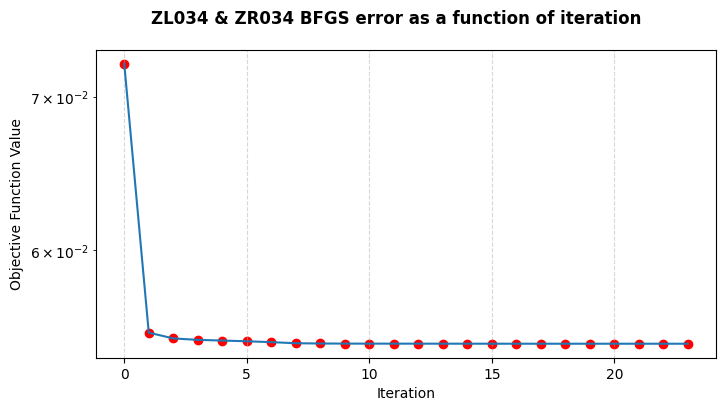

In [57]:
# plot the error as a function of iteration
errs = [obj(x) for x in res.allvecs]

fig, ax = plt.subplots(1, 1, figsize=(8,4))


ax.plot(errs)
ax.scatter(range(len(errs)), errs, color="red")
ax.set_xlabel("Iteration")
ax.set_ylabel("Objective Function Value")
ax.grid(linestyle="--", alpha=0.5)
ax.set_yscale("log")

fig.suptitle("ZL034 & ZR034 BFGS error as a function of iteration", fontsize=12, fontweight="bold");

In [58]:
q_rrp = np.array(res.x[:4])/np.linalg.norm(np.array(res.x[:4]))
q_cm_zl_0 = np.array(res.x[4:8])/np.linalg.norm(np.array(res.x[4:8]))
q_cm_zl_1 = np.array(res.x[8:12])/np.linalg.norm(np.array(res.x[8:12]))
q_cm_zr_0 = np.array(res.x[12:16])/np.linalg.norm(np.array(res.x[12:16]))
q_cm_zr_1 = np.array(res.x[16:20])/np.linalg.norm(np.array(res.x[16:20]))
print(f"Final function:{res.fun:.6f}")
print(f"Final Jacobian:{np.linalg.norm(res.jac):.6f}")
print(f"q_rrp:{list(q_rrp)}")
print(f"q_cm_zl_0:{list(q_cm_zl_0)}")
print(f"q_cm_zl_1:{list(q_cm_zl_1)}")
print(f"q_cm_zr_0:{list(q_cm_zr_0)}")
print(f"q_cm_zr_1:{list(q_cm_zr_1)}")

# q_rrp = [ 5.51277082e-05, 3.46611661e-04, -7.85697625e-04, -9.99999630e-01]
# q_cm_zl_0 = [0.49055634, 0.504521, 0.50681733, 0.49794501]
# q_cm_zl_1 = [ 7.91548065e-05, -1.18646514e-04, -1.80799581e-04, 9.99999973e-01]
# q_cm_zr_0 = [0.50379237, 0.48965398, 0.49896909, 0.5074072 ]
# q_cm_zr_1 = [ 3.14480239e-05, -1.09409422e-05, -1.79232289e-04, 9.99999983e-01]

Final function:0.054631
Final Jacobian:0.000002
q_rrp:[-0.00064014090651153, 0.00021173702266448464, 0.02252935707403783, -0.9997459544588733]
q_cm_zl_0:[0.46093647339017635, 0.4987218660240462, 0.5679881425558777, 0.4649769217542357]
q_cm_zl_1:[0.0014262914393661972, 0.004061394948665182, 0.0020356557478415733, 0.9999886633704789]
q_cm_zr_0:[0.47540230619268226, 0.4823845338684905, 0.5587099518734423, 0.4786867435272613]
q_cm_zr_1:[0.0008042254204692765, 0.003346002262561005, 0.0020623399909897454, 0.9999919520896623]


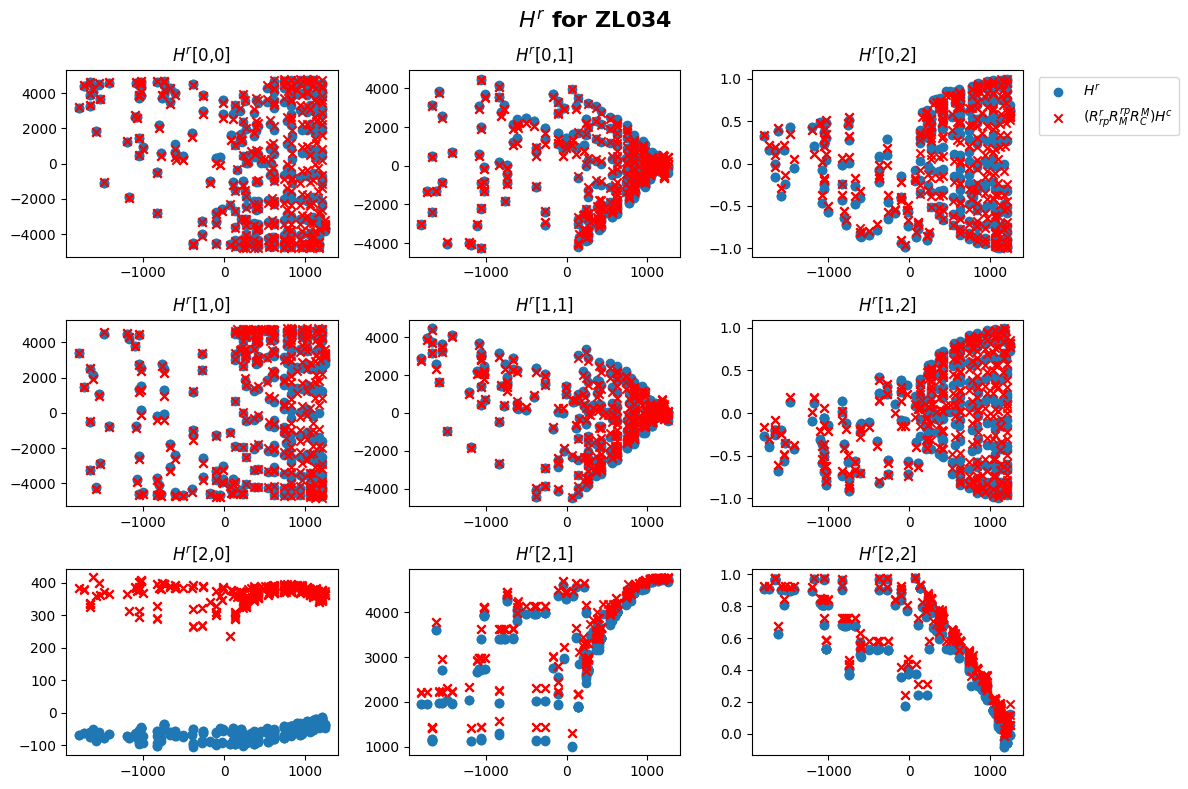

In [59]:
# plot H_r matrix as a function of f
H_r_data_zl = []
H_r_model_zl = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zl.shape[0]):
 # compute the rotation R_rpm
  rot_rpm = R.from_matrix(get_R_rpm(i, zl))
  
  # slerp between q_cm_zl_a and q_cm_zl_b
  f = zl["fmc"][i]
  rot_mc_0 = R.from_quat(q_cm_zl_0)
  rot_mc_1 = R.from_quat(q_cm_zl_1)
  # rot_mc = rot_mc_0 * ((rot_mc_0.inv() * rot_mc_1)**((f-left_f_min)/(left_f_max-left_f_min)))
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))

  # compute R_rc 
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()
  
  H_c = get_KC(i, zl).T
  H_r_model_zl.append(R_rc @ H_c)

  # data
  H_r_data_zl.append(get_H_r_data(i, zl))

fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zl["fmc"], [H[r,c] for H in H_r_data_zl], label="expectation")
    ax[r,c].scatter(zl["fmc"], [H[r, c] for H in H_r_model_zl], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) H^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle("$H^r$ for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

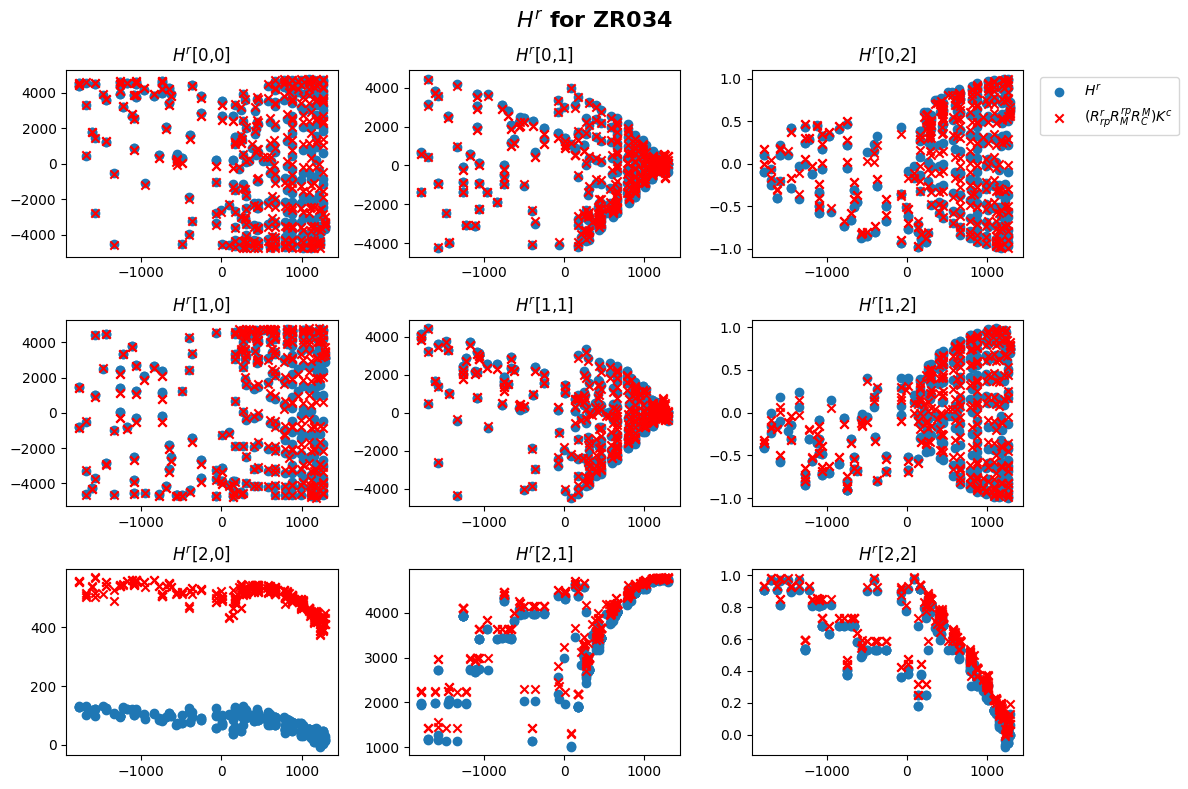

In [60]:
# plot H_r matrix as a function of f
H_r_data_zr = []
H_r_model_zr = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zr.shape[0]):
 # compute the rotation R_rpm
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  
  # slerp between q_cm_zr_a and q_cm_zr_b
  f = zr["fmc"][i]
  rot_mc_0 = R.from_quat(q_cm_zr_0)
  rot_mc_1 = R.from_quat(q_cm_zr_1)
  # rot_mc = rot_mc_0 * ((rot_mc_0.inv() * rot_mc_1)**((f-right_f_min)/(right_f_max-right_f_min)))
  rot_mc = rot_mc_0 * (rot_mc_1**(f/1000))

  # compute R_rc 
  rot_rc = rot_rrp * rot_rpm * rot_mc
  R_rc = rot_rc.as_matrix()
  
  H_c = get_KC(i, zr).T
  H_r_model_zr.append(R_rc @ H_c)

  # data
  H_r_data_zr.append(get_H_r_data(i, zr))

fig, ax = plt.subplots(3, 3, figsize=(12,8))

for r in range(3):
  for c in range(3):

    ax[r,c].scatter(zr["fmc"], [H[r,c] for H in H_r_data_zr], label="expectation")
    ax[r,c].scatter(zr["fmc"], [H[r, c] for H in H_r_model_zr], color="red", marker='x', label="model")
    ax[r,c].set_title(f"$H^r$[{r},{c}]")

ax[0,2].legend(["$H^r$", "$(R^r_{rp} R^{rp}_M R^M_C) K^c$"], bbox_to_anchor=(1.6,1))
fig.suptitle("$H^r$ for ZR034", fontsize=16, fontweight="bold")
fig.tight_layout()

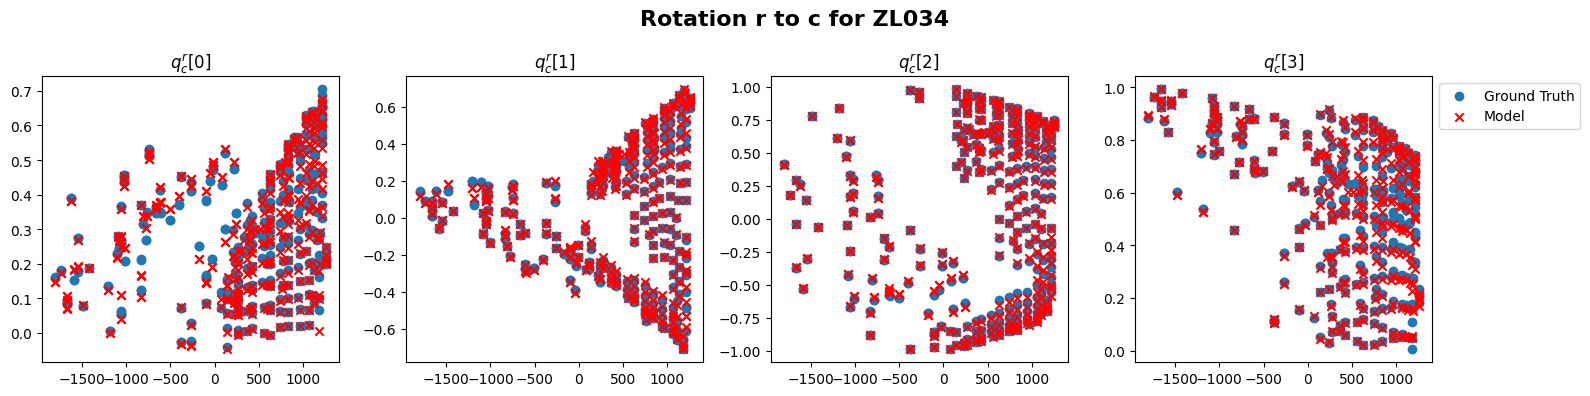

In [61]:
# compute quaternion for rotations from r to c from data 
q_rc_model = []
q_rc_data = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zl.shape[0]):
  # compute quaternions from data
  H_r = get_H_r_data(i, zl)
  H_c = get_KC(i, zl).T
  rot_rc_data = R.from_matrix(H_r @ np.linalg.inv(H_c))
  q_rc_d = rot_rc_data.as_quat(canonical=True)
  q_rc_data.append(q_rc_d)

  # compute quaternion from model
  f = zl["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zl))
  rot_mc = R.from_quat(q_cm_zl_0) * (R.from_quat(q_cm_zl_1)**(f/1000))
  rot_rc = rot_rrp * rot_rpm * rot_mc
  q_rc_m = rot_rc.as_quat(canonical=True)
  q_rc_model.append(q_rc_m)

# plot each of the quaternion
fig, ax = plt.subplots(1,4, figsize=(16,4))

for i in range(4):
  ax[i].scatter(zl["fmc"], [q[i] for q in q_rc_data], label="data")
  ax[i].scatter(zl["fmc"], [q[i] for q in q_rc_model], color="red", marker='x', label="model")
  ax[i].set_title(f"$q^r_c$[{i}]")

ax[3].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))
fig.suptitle("Rotation r to c for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()

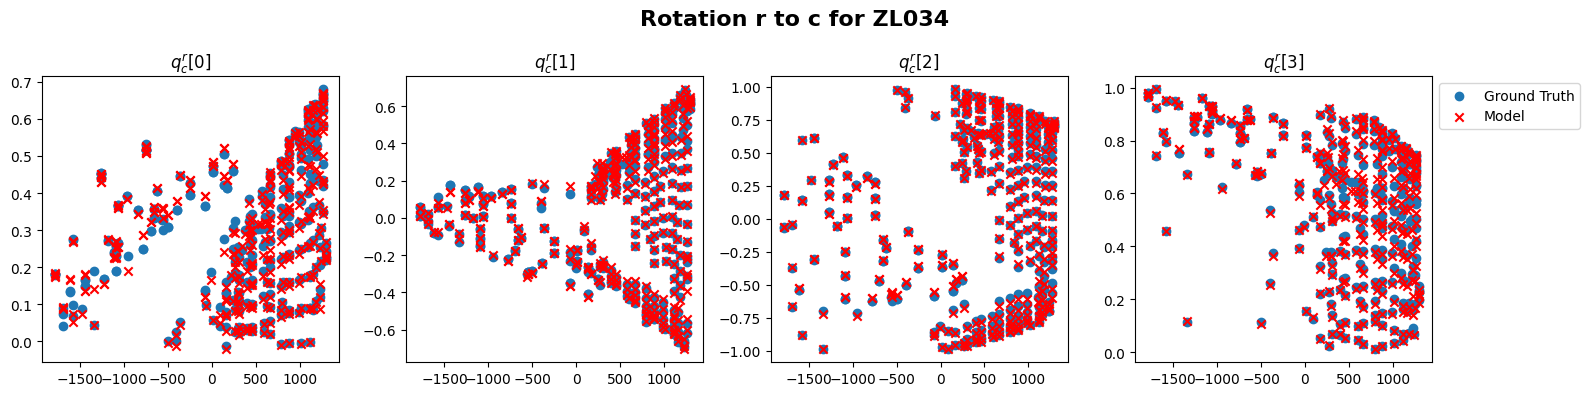

In [62]:
# compute quaternion for rotations from r to c from data 
q_rc_model = []
q_rc_data = []

rot_rrp = R.from_quat(q_rrp)
for i in range(zr.shape[0]):
  # compute quaternions from data
  H_r = get_H_r_data(i, zr)
  H_c = get_KC(i, zr).T
  rot_rc_data = R.from_matrix(H_r @ np.linalg.inv(H_c))
  q_rc_d = rot_rc_data.as_quat(canonical=True)
  q_rc_data.append(q_rc_d)

  # compute quaternion from model
  f = zr["fmc"][i]
  rot_rpm = R.from_matrix(get_R_rpm(i, zr))
  rot_mc = R.from_quat(q_cm_zr_0) * (R.from_quat(q_cm_zr_1)**(f/1000))
  rot_rc = rot_rrp * rot_rpm * rot_mc
  q_rc_m = rot_rc.as_quat(canonical=True)
  q_rc_model.append(q_rc_m)

# plot each of the quaternion
fig, ax = plt.subplots(1,4, figsize=(16,4))

for i in range(4):
  ax[i].scatter(zr["fmc"], [q[i] for q in q_rc_data], label="data")
  ax[i].scatter(zr["fmc"], [q[i] for q in q_rc_model], color="red", marker='x', label="model")
  ax[i].set_title(f"$q^r_c$[{i}]")

ax[3].legend(["Ground Truth", "Model"], bbox_to_anchor=(1,1))
fig.suptitle("Rotation r to c for ZL034", fontsize=16, fontweight="bold")
fig.tight_layout()